# Stage 2 EDA Pipeline Demo

This notebook demonstrates the current `strawberry.stage2_eda` pipeline using the mock manifests in `data/02_processed/strawberry/manifests_mock/`. It shows the expected inputs, runs validation, generates the EDA report and graphs, and previews selected outputs.

## 1. Locate Project and Import Pipeline Modules

In [4]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / 'README.md').exists() and (path / 'src').exists() and (path / 'data').exists():
            return path
    raise FileNotFoundError('Could not find repository root from current notebook location')


ROOT = find_project_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from strawberry.stage2_eda.eda import create_graphs, run_from_manifests
from strawberry.stage2_eda.io import load_csv_if_exists, load_summary_json
from strawberry.stage2_eda.report import build_basic_report
from strawberry.stage2_eda.validate import collect_validation_issues

MANIFEST_DIR = ROOT / 'data' / '02_processed' / 'strawberry' / 'manifests_mock'
REPORT_DIR = ROOT / 'output' / 'reports' / 'eda'
GRAPH_DIR = ROOT / 'output' / 'graphs' / 'eda'

def display_path(path: Path) -> str:
    return path.resolve().relative_to(ROOT).as_posix()


print('Project root: .')
print(f'Manifest dir: {display_path(MANIFEST_DIR)}')
print(f'Report dir: {display_path(REPORT_DIR)}')
print(f'Graph dir: {display_path(GRAPH_DIR)}')

Project root: .
Manifest dir: data/02_processed/strawberry/manifests_mock
Report dir: output/reports/eda
Graph dir: output/graphs/eda


## 2. Load EDA Input Manifests

The current EDA pipeline expects these Stage 2 / Stage 2.5 manifests:

- `frame_manifest.csv`
- `labels.csv`
- `eol_anchors.csv`
- `numeric_mapping.csv`
- `excluded_frames.csv`
- optional `preprocessing_summary.json`

In [5]:
frame_manifest = load_csv_if_exists(MANIFEST_DIR / 'frame_manifest.csv')
labels = load_csv_if_exists(MANIFEST_DIR / 'labels.csv')
eol_anchors = load_csv_if_exists(MANIFEST_DIR / 'eol_anchors.csv')
numeric_mapping = load_csv_if_exists(MANIFEST_DIR / 'numeric_mapping.csv')
excluded_frames = load_csv_if_exists(MANIFEST_DIR / 'excluded_frames.csv')
summary = load_summary_json(MANIFEST_DIR / 'preprocessing_summary.json')

manifest_summary = pd.DataFrame(
    [
        {'manifest': 'frame_manifest.csv', 'rows': len(frame_manifest), 'columns': len(frame_manifest.columns)},
        {'manifest': 'labels.csv', 'rows': len(labels), 'columns': len(labels.columns)},
        {'manifest': 'eol_anchors.csv', 'rows': len(eol_anchors), 'columns': len(eol_anchors.columns)},
        {'manifest': 'numeric_mapping.csv', 'rows': len(numeric_mapping), 'columns': len(numeric_mapping.columns)},
        {'manifest': 'excluded_frames.csv', 'rows': len(excluded_frames), 'columns': len(excluded_frames.columns)},
    ]
)
manifest_summary

,manifest,rows,columns
0,frame_manifest.csv,5,26
1,labels.csv,5,27
2,eol_anchors.csv,3,11
3,numeric_mapping.csv,5,13
4,excluded_frames.csv,2,22


## 3. Preview Key Tables

In [6]:
display(Markdown('### Frame Manifest'))
display(frame_manifest.head())

display(Markdown('### Labels'))
display(labels.head())

display(Markdown('### Excluded Frames'))
display(excluded_frames.head())

### Frame Manifest

,experiment_id,fruit_type,fruit_id,roi_id,frame_id,timestamp,image_path,raw_path,source_path,mask_path,...,color_b_mean,lab_L,lab_a,lab_b,temperature_anomaly,humidity_anomaly,sensor_status,motion_detected,mask_valid,sequence_index
0,EXP001,Strawberry,F01,R01,1,2025-06-01T08:00:00Z,data/images/F01_0001.png,data/01_raw/F01_0001.jpg,data/source/F01_0001.raw,data/masks/F01_0001_mask.png,...,95,56.2,14.1,21.3,False,False,ok,True,True,0
1,EXP001,Strawberry,F01,R01,2,2025-06-01T12:00:00Z,data/images/F01_0002.png,data/01_raw/F01_0002.jpg,data/source/F01_0002.raw,data/masks/F01_0002_mask.png,...,94,56.8,13.7,20.9,False,False,ok,True,True,1
2,EXP001,Strawberry,F02,R02,1,2025-06-02T09:30:00Z,data/images/F02_0001.png,data/01_raw/F02_0001.jpg,data/source/F02_0001.raw,data/masks/F02_0001_mask.png,...,96,55.5,12.9,19.8,False,False,ok,False,True,0
3,EXP001,Strawberry,F02,R02,2,2025-06-02T13:15:00Z,data/images/F02_0002.png,data/01_raw/F02_0002.jpg,data/source/F02_0002.raw,data/masks/F02_0002_mask.png,...,0,0.0,0.0,0.0,True,True,sensor_gap,True,False,1
4,EXP001,Strawberry,F03,R03,1,2025-06-03T10:00:00Z,data/images/F03_0001.png,data/01_raw/F03_0001.jpg,data/source/F03_0001.raw,data/masks/F03_0001_mask.png,...,97,54.9,12.5,18.6,False,False,ok,True,True,0


### Labels

,experiment_id,fruit_type,fruit_id,roi_id,raw_path,image_path,timestamp,eol_timestamp,rul_hours,temperature_c,...,label_status,temperature_anomaly,humidity_anomaly,sensor_status,color_r_mean,color_g_mean,color_b_mean,lab_L,lab_a,lab_b
0,EXP001,Strawberry,F01,R01,data/01_raw/F01_0001.jpg,data/images/F01_0001.png,2025-06-01T08:00:00Z,2025-06-04T08:00:00Z,72.00,20.3,...,final,False,False,ok,123,110,95,56.2,14.1,21.3
1,EXP001,Strawberry,F01,R01,data/01_raw/F01_0002.jpg,data/images/F01_0002.png,2025-06-01T12:00:00Z,2025-06-04T08:00:00Z,68.00,20.8,...,final,False,False,ok,125,112,94,56.8,13.7,20.9
2,EXP001,Strawberry,F02,R02,data/01_raw/F02_0001.jpg,data/images/F02_0001.png,2025-06-02T09:30:00Z,2025-06-05T09:00:00Z,71.50,21.1,...,preliminary,False,False,ok,120,108,96,55.5,12.9,19.8
3,EXP001,Strawberry,F02,R02,data/01_raw/F02_0002.jpg,data/images/F02_0002.png,2025-06-02T13:15:00Z,2025-06-05T09:00:00Z,67.75,21.5,...,final,False,False,ok,122,109,95,56.1,13.2,20.5
4,EXP001,Strawberry,F03,R03,data/01_raw/F03_0001.jpg,data/images/F03_0001.png,2025-06-03T10:00:00Z,2025-06-06T10:00:00Z,72.00,19.9,...,final,False,False,ok,118,109,97,54.9,12.5,18.6


### Excluded Frames

,experiment_id,fruit_type,fruit_id,roi_id,timestamp,raw_path,processed_path,reason,exclude_reason,mask_reason,...,notes,roi_position,mask_area,foreground_ratio,color_r_mean,color_g_mean,color_b_mean,lab_L,lab_a,lab_b
0,EXP001,Strawberry,F04,R04,2025-06-01T08:15:00Z,data/01_raw/F04_0001.jpg,data/images/F04_0001.png,blurred,blurred,image missing,...,blurred capture,R04,0,0.0,110,98,84,54.2,12.0,19.4
1,EXP001,Strawberry,F05,R05,2025-06-02T11:00:00Z,data/01_raw/F05_0001.jpg,data/images/F05_0001.png,occluded,occluded,mask invalid,...,occluded ROI,R05,0,0.0,112,100,86,54.8,12.3,19.9


## 4. Run Validation Checks

These checks are now integrated into the generated EDA report. Running them separately in the notebook makes protocol issues visible before generating graphs.

In [7]:
validation_issues = collect_validation_issues(frame_manifest, labels, eol_anchors)

validation_rows = []
for check_name, issues in validation_issues.items():
    if issues:
        for issue in issues:
            validation_rows.append({'check': check_name, 'status': 'issue', 'detail': issue})
    else:
        validation_rows.append({'check': check_name, 'status': 'passed', 'detail': ''})

pd.DataFrame(validation_rows)

,check,status,detail
0,labels_eol_consistency,passed,
1,frame_manifest_roi_timeline,passed,
2,firmness_availability,passed,


## 5. Build the EDA Report In Memory

This cell shows the report content before writing it to `output/reports/eda/dataset_inventory.md`.

In [9]:
report_lines = build_basic_report(
    frame_manifest,
    labels,
    eol_anchors,
    numeric_mapping,
    excluded_frames,
    summary,
    REPORT_DIR,
    validation_issues=validation_issues,
    manifest_dir=MANIFEST_DIR,
    graph_dir=GRAPH_DIR,
)

display(Markdown('\n'.join(report_lines[:80])))

# EDA Report


## Paths

- `MANIFEST_DIR`: `data/02_processed/strawberry/manifests_mock`
- `REPORT_DIR`: `output/reports/eda`
- `GRAPH_DIR`: `output/graphs/eda`

## Available files

- `frame_manifest.csv`: 5 rows
- `labels.csv`: 5 rows
- `eol_anchors.csv`: 3 rows
- `numeric_mapping.csv`: 5 rows
- `excluded_frames.csv`: 2 rows

## Validation checks

- `labels_eol_consistency`: passed
- `frame_manifest_roi_timeline`: passed
- `firmness_availability`: passed
- all validation checks passed

## Frame totals

- raw frames: unknown (not available in preprocessing summary)
- processed frames: 5
- excluded frames: 2

## Missing values

- Frame manifest
  - `timestamp`: 0/5 missing (0.0%)
  - `fruit_id`: 0/5 missing (0.0%)
  - `fruit_type`: 0/5 missing (0.0%)
  - `image_path`: 0/5 missing (0.0%)
  - `mask_path`: 0/5 missing (0.0%)
  - `temperature_c`: 0/5 missing (0.0%)
  - `humidity_pct`: 0/5 missing (0.0%)
  - `mask_valid`: 0/5 missing (0.0%)

- Label manifest
  - `timestamp`: 0/5 missing (0.0%)
  - `fruit_id`: 0/5 missing (0.0%)
  - `rul_hours`: 0/5 missing (0.0%)
  - `temperature_c`: 0/5 missing (0.0%)
  - `humidity_pct`: 0/5 missing (0.0%)
  - `firmness_avg`: 0/5 missing (0.0%)

## Sequence lengths per fruit

- fruit count sequences: 3 fruits
- frame count per fruit: min=1, median=2, max=2
- top 10 fruits by frame count: {'F01': 2, 'F02': 2, 'F03': 1}
- sequence index span per fruit: min=0, median=1, max=1

## Sensor anomalies and ranges

- `Frame manifest` temperature_c range: 19.9 to 21.5
- `Frame manifest` humidity_pct range: 44.7 to 47.0
- `Frame manifest` temperature_anomaly count: 1
- `Frame manifest` humidity_anomaly count: 1
- `Frame manifest` sensor_status counts: {'ok': 4, 'sensor_gap': 1}

- `Label manifest` temperature_c range: 19.9 to 21.5
- `Label manifest` humidity_pct range: 44.7 to 47.0
- `Label manifest` temperature_anomaly count: 0
- `Label manifest` humidity_anomaly count: 0
- `Label manifest` sensor_status counts: {'ok': 5}

## Frame counts

- unique `experiment_id`: 1
- frame counts by experiment_id (top 10): {'EXP001': 5}
- unique `fruit_type`: 1
- frame counts by fruit_type: {'Strawberry': 5}
- frame count by date (top 10): {datetime.date(2025, 6, 1): 2, datetime.date(2025, 6, 2): 2, datetime.date(2025, 6, 3): 1}
- unique `fruit_id`: 3
- frame counts by fruit_id (top 10): {'F01': 2, 'F02': 2, 'F03': 1}

## 6. Run the Full EDA Pipeline

This calls the same entry point used by the command-line runner. It writes the report and all available graphs to the project output folders.

In [10]:
run_from_manifests(ROOT)

reports = sorted(REPORT_DIR.glob('*'))
graphs = sorted(GRAPH_DIR.glob('*.png'))

print(f'Reports generated: {len(reports)}')
for path in reports:
    print(f'- {path.relative_to(ROOT)}')

print(f'Graphs generated: {len(graphs)}')
for path in graphs:
    print(f'- {path.relative_to(ROOT)}')

Saved report: output/reports/eda/dataset_inventory.md
Saved graph: output/graphs/eda/frame_count_by_date.png
Saved graph: output/graphs/eda/frame_count_by_date_and_fruit.png
Saved graph: output/graphs/eda/roi_layout_comparison.png
Saved graph: output/graphs/eda/frame_count_by_fruit.png
Saved graph: output/graphs/eda/frame_count_by_experiment.png
Saved graph: output/graphs/eda/frame_count_by_fruit_type.png
Saved graph: output/graphs/eda/mask_valid_over_time.png
Saved graph: output/graphs/eda/mask_valid_ratio_over_time.png
Saved graph: output/graphs/eda/excluded_frame_reasons.png
Saved graph: output/graphs/eda/excluded_frame_mask_reasons.png
Saved graph: output/graphs/eda/excluded_frames_by_roi.png
Saved graph: output/graphs/eda/excluded_frames_roi_position_distribution.png
Saved graph: output/graphs/eda/excluded_frames_by_fruit.png
Saved graph: output/graphs/eda/label_count_by_fruit.png
Saved graph: output/graphs/eda/rul_distribution_by_fruit.png
Saved graph: output/graphs/eda/rul_over_

## 7. Preview Selected Graphs

### `frame_count_by_date_and_fruit.png`

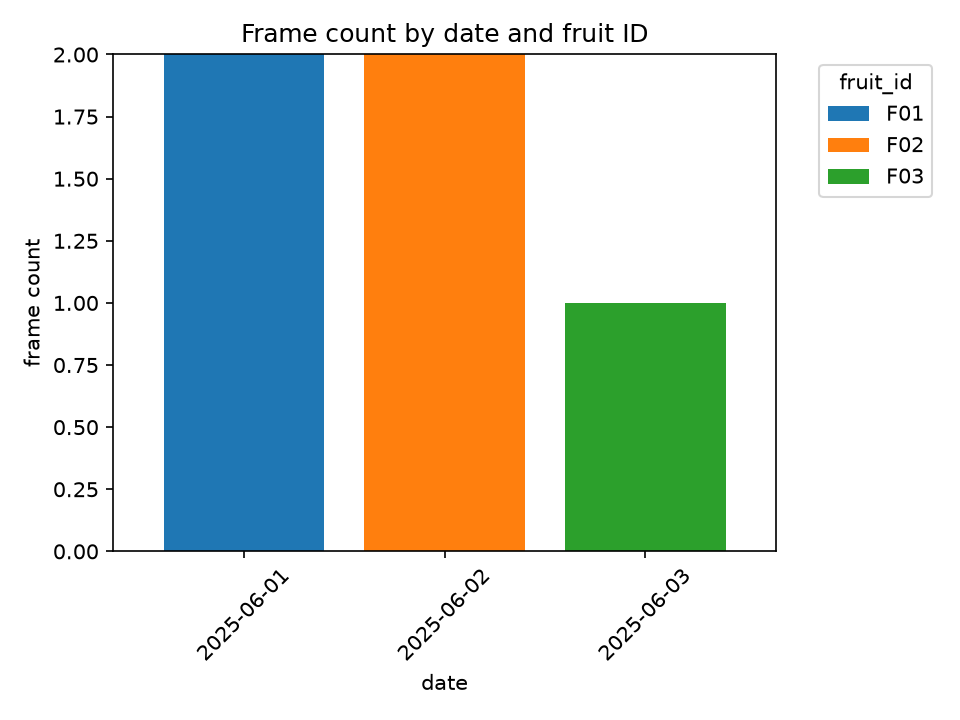

### `rul_distribution_by_fruit.png`

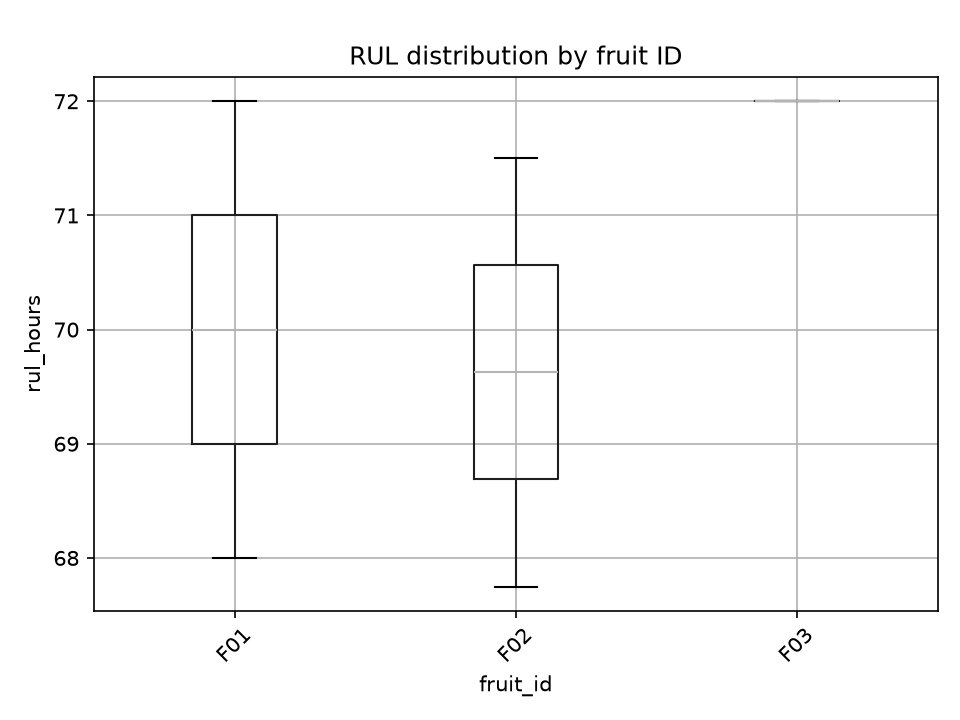

### `excluded_frame_reasons.png`

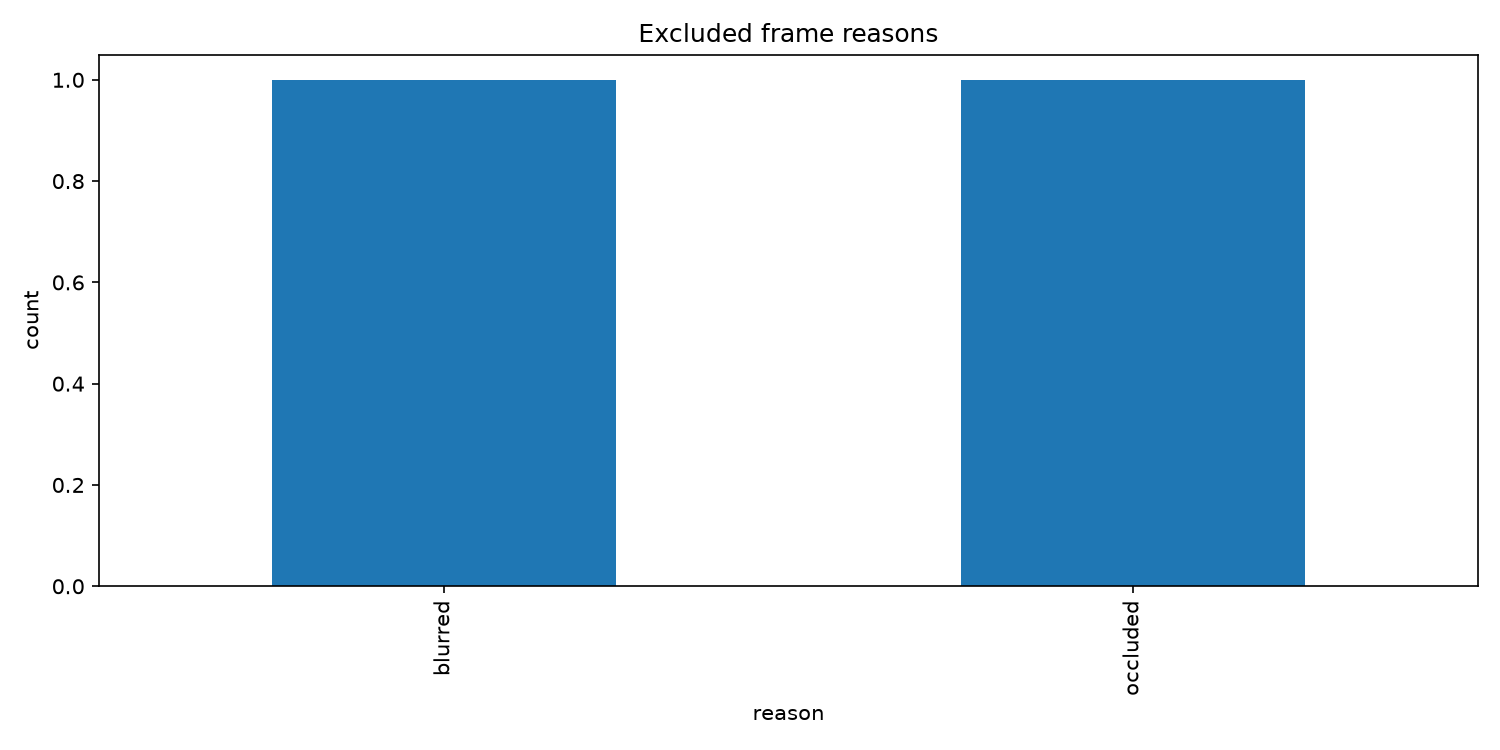

### `color_r_mean_over_time.png`

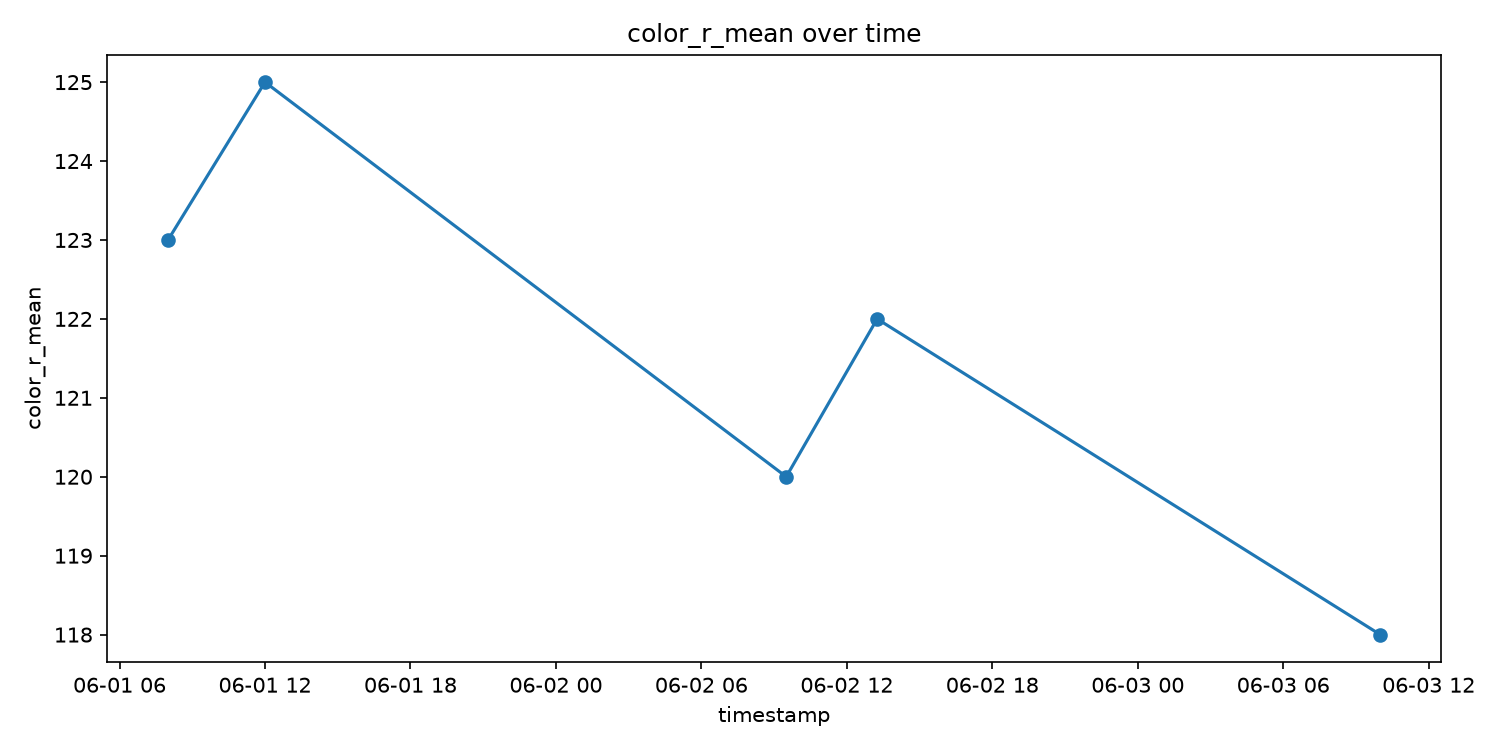

### `lab_L_over_time.png`

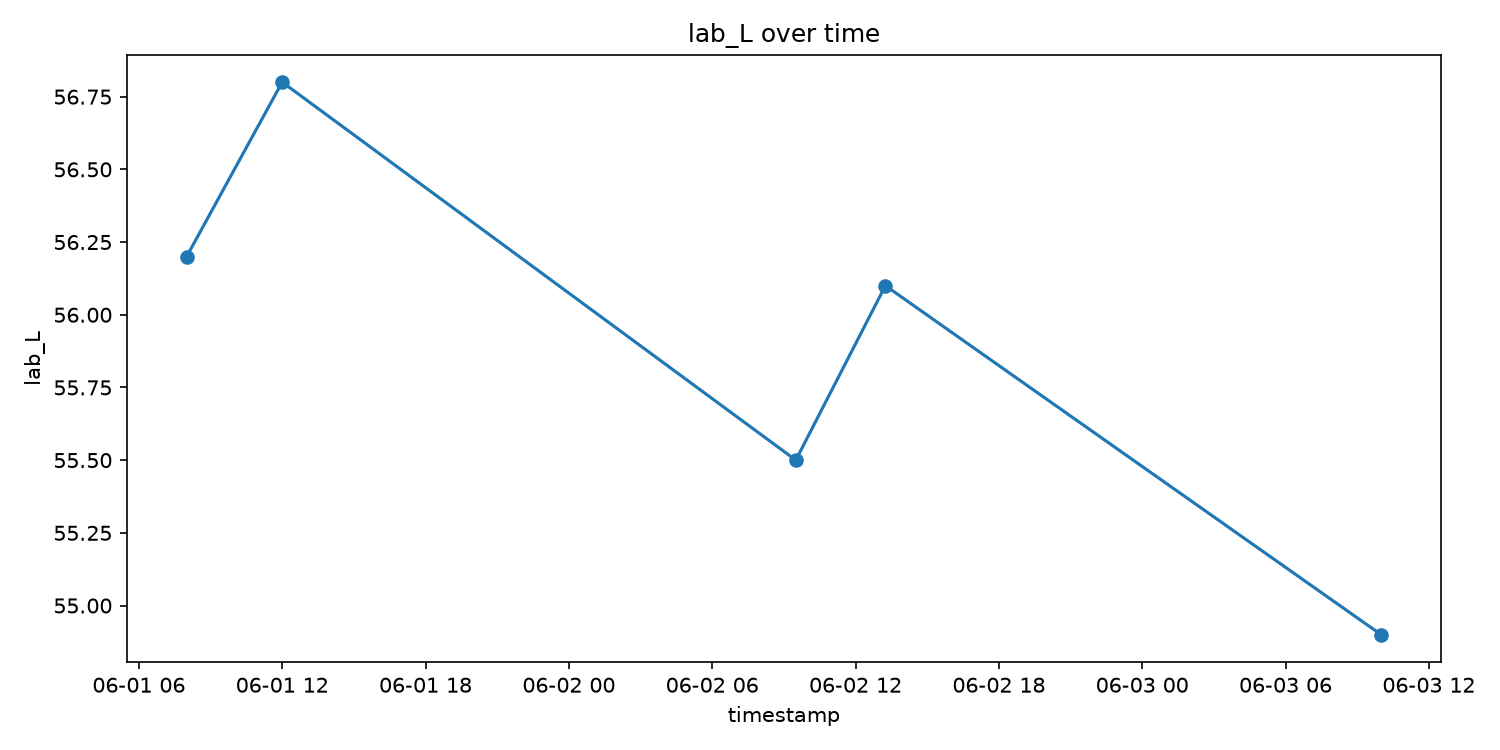

In [11]:
preview_graphs = [
    'frame_count_by_date_and_fruit.png',
    'rul_distribution_by_fruit.png',
    'excluded_frame_reasons.png',
    'color_r_mean_over_time.png',
    'lab_L_over_time.png',
]

for graph_name in preview_graphs:
    graph_path = GRAPH_DIR / graph_name
    if graph_path.exists():
        display(Markdown(f'### `{graph_name}`'))
        display(Image(filename=str(graph_path)))
    else:
        display(Markdown(f'- Missing `{graph_name}`'))

## 8. Notebook Takeaways

- The notebook uses the same `strawberry.stage2_eda` modules as the command-line runner.
- Validation results are included in the generated report.
- Color trend plotting uses the documented `color_*` and `lab_*` manifest columns.
- Any validation issue in this demo reflects the current mock manifest data, not a notebook-specific check.